# Data Mining Lab 1
## Data Understanding + Data Cleaning + Visualization  
**Dataset:** StudentsPerformance.csv

**Зорилго:**  
- Бодит dataset ашиглан өгөгдлийг унших, таних  
- Алдаа, дутуу утга, давхардлыг шалгаж цэвэрлэх  
- Энгийн график дүрслэлээр pattern-ийг олж харах  



In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 120)


## 0) Dataset унших

**StudentsPerformance.csv** файлыг ашиглана.


In [16]:
df = pd.read_csv("StudentsPerformance.csv")
df.head()


,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


## 1) Data Understanding (өгөгдлөө таних)

### 1.1 Dataset-ийн бүтэц
- Хэдэн мөр, хэдэн баганатай вэ?  
- Аль баганууд numeric байна вэ?  
- Аль багана нь ирээдүйд prediction хийхэд тохиромжтой вэ?


In [17]:
print("Shape:", df.shape)
print("Columns:", list(df.columns))
df.dtypes


Shape: (1000, 8)
Columns: ['gender', 'race/ethnicity', 'parental level of education', 'lunch', 'test preparation course', 'math score', 'reading score', 'writing score']


gender                           str
race/ethnicity                   str
parental level of education      str
lunch                            str
test preparation course          str
math score                     int64
reading score                  int64
writing score                  int64
dtype: object

### 1.2 Missing болон duplicate шалгах

- Аль баганад missing value байна вэ?  
- Давхардсан мөр байгаа эсэх?


In [18]:
# Missing values
df.isna().sum()


gender                         0
race/ethnicity                 0
parental level of education    0
lunch                          0
test preparation course        0
math score                     0
reading score                  0
writing score                  0
dtype: int64

In [19]:
# Duplicate rows
df.duplicated().sum()


np.int64(0)

### 1.3 Үндсэн статистик

Эндээс:
- Math, Reading, Writing score-уудын ерөнхий тархалтыг харна  
- Аль score хамгийн өндөр дундажтай байна вэ?


In [20]:
df.describe()


,math score,reading score,writing score
count,1000.00000,1000.000000,1000.000000
mean,66.08900,69.169000,68.054000
std,15.16308,14.600192,15.195657
min,0.00000,17.000000,10.000000
25%,57.00000,59.000000,57.750000
50%,66.00000,70.000000,69.000000
75%,77.00000,79.000000,79.000000
max,100.00000,100.000000,100.000000



1. Gender ба score-уудын хооронд ялгаа байна уу? (таамаг)  
2. Lunch төрлөөс score хамаарах уу?  
3. Аль score (math, reading, writing) хамгийн тогтвортой мэт харагдаж байна вэ?


## 2) Data Cleaning (өгөгдөл цэвэрлэх)

Энэ dataset-д ихэнхдээ missing бага эсвэл байхгүй байдаг.  
Гэхдээ дараах алхмуудыг **заавал шалгана**:

- Missing value  
- Category data-г ялгаж харах  
- Numeric data-г тусад нь авч үзэх


In [21]:
# Numeric болон categorical баганууд
num_cols = df.select_dtypes(include=np.number).columns
cat_cols = df.select_dtypes(exclude=np.number).columns

print("Numeric columns:", list(num_cols))
print("Categorical columns:", list(cat_cols))


Numeric columns: ['math score', 'reading score', 'writing score']
Categorical columns: ['gender', 'race/ethnicity', 'parental level of education', 'lunch', 'test preparation course']


## 3) Visualization (график дүрслэл)

Энд бид өгөгдөл доторх **pattern-ийг нүдээрээ олж харна**.


### 3.1 Histogram – Math score
- Дийлэнх оюутнууд аль score орчимд байна вэ?


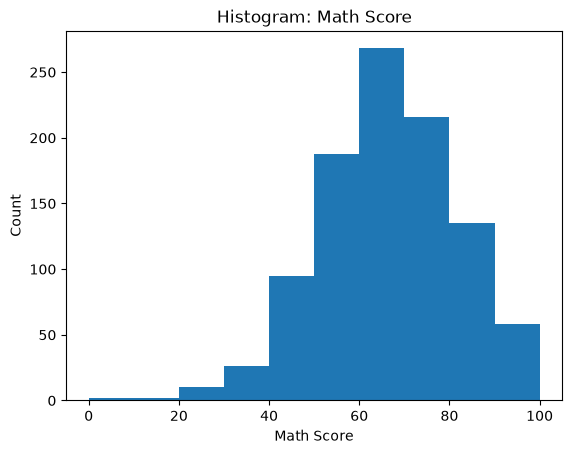

In [22]:
plt.figure()
plt.hist(df['math score'], bins=10)
plt.title("Histogram: Math Score")
plt.xlabel("Math Score")
plt.ylabel("Count")
plt.show()


### 3.2 Scatter – Math vs Reading
- Эдгээр хоёр score хоорондоо холбоотой юу?


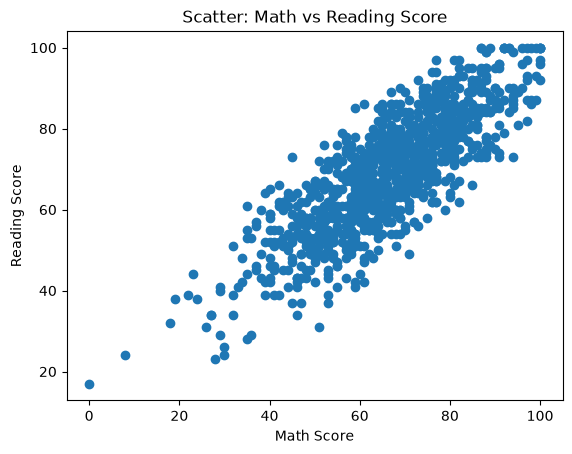

In [23]:
plt.figure()
plt.scatter(df['math score'], df['reading score'])
plt.title("Scatter: Math vs Reading Score")
plt.xlabel("Math Score")
plt.ylabel("Reading Score")
plt.show()


### 3.3 Boxplot – Gender vs Math Score
- Gender хооронд ялгаа ажиглагдаж байна уу?


<Figure size 640x480 with 0 Axes>

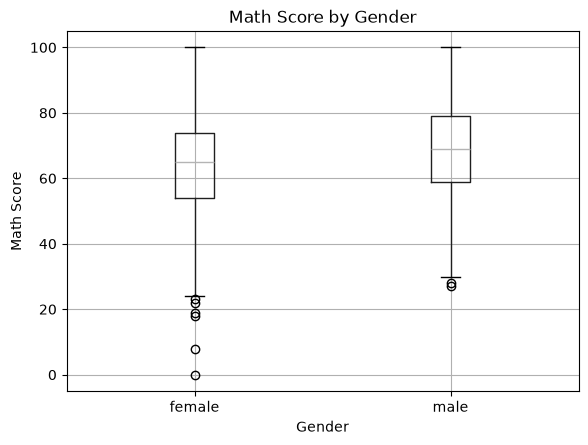

In [24]:
plt.figure()
df.boxplot(column='math score', by='gender')
plt.title("Math Score by Gender")
plt.suptitle("")
plt.xlabel("Gender")
plt.ylabel("Math Score")
plt.show()


### 3.4 Correlation Heatmap (numeric features)

- Math, Reading, Writing score-уудын correlation-ийг харна  
- Аль хоёр нь хамгийн өндөр холбоотой вэ?


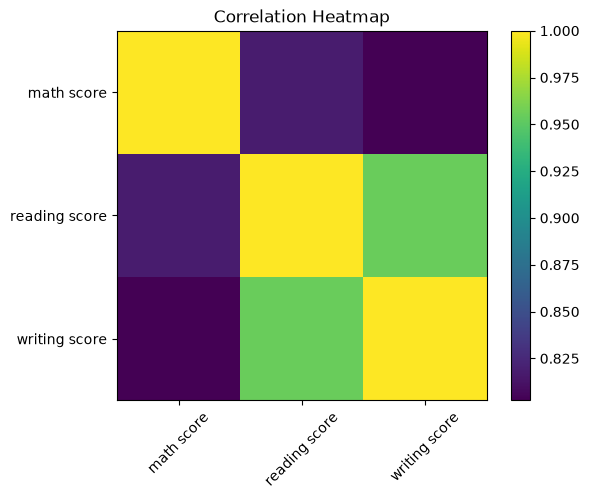

,math score,reading score,writing score
math score,1.000000,0.817580,0.802642
reading score,0.817580,1.000000,0.954598
writing score,0.802642,0.954598,1.000000


In [25]:
scores = df[['math score','reading score','writing score']]
corr = scores.corr()

plt.figure()
plt.imshow(corr)
plt.colorbar()
plt.xticks(range(len(scores.columns)), scores.columns, rotation=45)
plt.yticks(range(len(scores.columns)), scores.columns)
plt.title("Correlation Heatmap")
plt.show()

corr


## TASK A: Feature Analysis

Доорх асуултуудад **Python код бичиж** хариулна уу.

1. Аль categorical feature (`gender`, `lunch`, `test preparation course`) нь
   math score-т хамгийн их ялгаа үүсгэж байна вэ?
2. Тухайн feature бүрээр math score-ийн **дундаж**-ийг тооцоол.
3. Ямар feature нь prediction хийхэд илүү ашигтай санагдаж байна вэ? (үгээр)

`groupby()` + `mean()` ашиглана уу.


In [26]:
for col in ['gender', 'lunch', 'test preparation course']:
    print(f"math score {col}  dundaj:")
    print(df.groupby(col)['math score'].mean().round(2))
    group_means = df.groupby(col)['math score'].mean()
    spread = group_means.max() - group_means.min()
    print(f"Zuruu: {spread:.2f}\n")

math score gender  dundaj:
gender
female    63.63
male      68.73
Name: math score, dtype: float64
Zuruu: 5.10

math score lunch  dundaj:
lunch
free/reduced    58.92
standard        70.03
Name: math score, dtype: float64
Zuruu: 11.11

math score test preparation course  dundaj:
test preparation course
completed    69.70
none         64.08
Name: math score, dtype: float64
Zuruu: 5.62



##  TASK B: Score Comparison

1. Math, Reading, Writing score-уудын **variance** (эсвэл std)-ийг тооцоол.
2. Аль score хамгийн их хэлбэлзэлтэй байна вэ?
3. Энэ нь суралцахад юуг илэрхийлж болох вэ? (үгээр)

 `var()` эсвэл `std()` ашиглана уу.


In [27]:
scores = df[['math score', 'reading score', 'writing score']]
print("Variance:")
print(scores.var().round(2))

most_var = scores.var().idxmax()
print(f"\nhamgiin ih helbelzeltei {most_var} ({scores.var().max():.2f})")

# 3) oyutnuudiin onoonii helbelzel barag ijil baina. iimd surah chadvar gol yalgaa uusgedeg

Variance:
math score       229.92
reading score    213.17
writing score    230.91
dtype: float64

hamgiin ih helbelzeltei writing score (230.91)


## TASK C: Simple Rule Thinking

Доорх энгийн дүрмүүдийг шалгаарай.

1. Math score ≥ 70 оюутнуудын дундаж Reading score хэд вэ?
2. Math score < 70 оюутнуудын дундаж Reading score хэд вэ?
3. Эдгээрийн ялгаа нь ямар **pattern**-ийг харуулж байна вэ?

Boolean filter + `mean()` ашиглана уу.


In [28]:
high = df[df['math score'] >= 70]
print(f"math 69+ Reading score: {high['reading score'].mean():.2f}")

low = df[df['math score'] < 70]
print(f"Math 70aas doosh Reading score: {low['reading score'].mean():.2f}")

# 3) math daa sain oyutnuud reading score-oo ch sain avch bna. iimd math daa sain bol reading undur avah bolomjtoi baina.

math 69+ Reading score: 80.26
Math 70aas doosh Reading score: 61.49


# Data Mining Lab 1 Тайлан 
## Student Performance Dataset

**Нэр:**  Буяндэлгэр
**Оюутны код:**  s22c008b
**Анги / Бүлэг:**  КУ5
**Огноо:**  9.21

---

## 1. Dataset-ийн ерөнхий мэдээлэл
- Мөрийн тоо: **1000**
- Баганын тоо: **8**
- Target variable (хэрэв байвал): 
ene dataset 1000 oyutnuudiin huis ,ugsaam, bolovsrol , 3 hicheeliin onoog haruulsan baina , oyutnuudin dundaj onoo oiroltsoogoor 60-70 baina.
---

## 2. Data Understanding (Өгөгдөл таних)

### Numeric Features
- **math score** (0–100): dundaj66.09, std 15.16
- **reading score** (17–100): dundaj 69.17, std 14.60 (hamgiin undur dundaj, hamgiin baga helbelzeltei)
- **writing score** (10–100): dundaj 68.05, std 15.20

### Categorical Features
- **gender**: female, male
- **race/ethnicity**: group A–E
- **parental level of education**: some college (226), associate's degree (222), high school (196), some high school (179), bachelor's degree (118), master's degree (59)
- **lunch**: standard, free/reduced
- **test preparation course**: none, completed

`describe()`aas ajiglagdsan zuils : 3 score iin dundaj barag ijil (66-69), std ~15 baina. undur onootoi oyutnuud buh hicheel deeree undur baih handlagtai baina. 

---

## 3. Data Cleaning (Өгөгдөл цэвэрлэгээ)
- Missing value байсан уу? **Үгүй** (`df.isna().sum()` none utga baihgui baisan)
- Хэрхэн шийдсэн бэ? missing baigaagui uchir fill hiigeegui
- Duplicate мөр байсан уу? **Үгүй** (`df.duplicated().sum()` = 0)

missing duplicate baigaagui uchir fill hiij uurchluhguigeer ashiglaj bolno gej bodoj baina.
---

## 4. Visualization ба Pattern

### Visualization 1
- Төрөл: **Histogram** (Math Score)
tarhalt ni 60-70 orchim baisan,. mun 0-20 onootoi heden oyutan tusgagsan baisan.

### Visualization 2
- Төрөл: **Scatter** (Math vs Reading)
math onoo undur oyutnuud reading ch undur avdag nygt holboog haruulj baina.
---

## 5. Correlation Analysis
- Хамгийн өндөр correlation-той хос: **reading score ба writing score (r = 0.955)**
unshih chadvar sain baidag oyutanuud bichih (hamgiin undur) chadvar ch sain baidag. 

---

## 6. Дүгнэлт
dataset ashiglan ugugduliig unshij , tseverlej , durslen harj uzlee. 
graphic dursleleer 3 score hoorondoo mash nygt holbootoi baina.(hamgiin undur ni readin writing) buguud hamgiin nuluutei feature bolohiig togtooloo.iimd prediction hiihed score uud hoorondo nygt holbootoi tul ur dun sain sain garna gej bodoj baina.

---

